In [4]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [6]:
load_dotenv()

True

In [14]:
from dotenv import load_dotenv
import os

load_dotenv(
    r"C:\Robin\AI course\complete-agentic-ai\6-Multi-AI-Agent\.env"
)

print(os.getenv("GOOGLE_API_KEY") is not None)

True


In [21]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    temperature=0.7
)

In [16]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [17]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [18]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [19]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

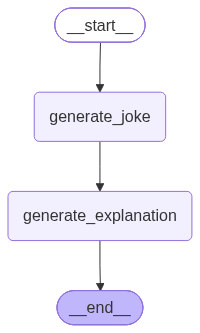

In [30]:
workflow

In [22]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'Football'}, config=config1)

c:\Robin\AI course\complete-agentic-ai\6-Multi-AI-Agent\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Robin\AI course\complete-agentic-ai\6-Multi-AI-Agent\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'topic': 'Football',
 'joke': [{'type': 'text',
   'text': 'A man manages to get a ticket right at the pitch-side halfway line for the Champions League Final. \n\nHe sits down, but notices that the seat right next to him is empty. \n\nThe guy sitting on the other side of the empty seat asks, "Who in their right mind would leave a seat like that empty for the biggest game of the year?"\n\nThe man replies, "Well, actually, I bought the ticket for my wife. We’ve been to every final together for the last 20 years, but she unfortunately passed away."\n\nThe other guy feels terrible. "Oh, I\'m so sorry to hear that. That\'s awful. But couldn\'t you have brought a friend, a neighbor, or a relative instead?"\n\nThe man shakes his head. "No... they’re all at the funeral."',
   'extras': {'signature': 'EosaCogaAWkUfRNVnHvm7sKZSUE+XNWBp+gPBPAGHZOb1lir/536izi/UwqxpWJwZnQw2IMwS18wCZoBLYf7x6b/rasKWGIsCPf6CtQjEisbQuTAtp+M8fh/r62scqgXGBbdKDxDcHfdZFeDM9BcP1tBp65p+EBcCknAmicL9AiLCW54oFzq3uK14kB6Z3PHcFc

In [23]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Football', 'joke': [{'type': 'text', 'text': 'A man manages to get a ticket right at the pitch-side halfway line for the Champions League Final. \n\nHe sits down, but notices that the seat right next to him is empty. \n\nThe guy sitting on the other side of the empty seat asks, "Who in their right mind would leave a seat like that empty for the biggest game of the year?"\n\nThe man replies, "Well, actually, I bought the ticket for my wife. We’ve been to every final together for the last 20 years, but she unfortunately passed away."\n\nThe other guy feels terrible. "Oh, I\'m so sorry to hear that. That\'s awful. But couldn\'t you have brought a friend, a neighbor, or a relative instead?"\n\nThe man shakes his head. "No... they’re all at the funeral."', 'extras': {'signature': 'EosaCogaAWkUfRNVnHvm7sKZSUE+XNWBp+gPBPAGHZOb1lir/536izi/UwqxpWJwZnQw2IMwS18wCZoBLYf7x6b/rasKWGIsCPf6CtQjEisbQuTAtp+M8fh/r62scqgXGBbdKDxDcHfdZFeDM9BcP1tBp65p+EBcCknAmicL9AiLCW54oFzq3

In [24]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Football', 'joke': [{'type': 'text', 'text': 'A man manages to get a ticket right at the pitch-side halfway line for the Champions League Final. \n\nHe sits down, but notices that the seat right next to him is empty. \n\nThe guy sitting on the other side of the empty seat asks, "Who in their right mind would leave a seat like that empty for the biggest game of the year?"\n\nThe man replies, "Well, actually, I bought the ticket for my wife. We’ve been to every final together for the last 20 years, but she unfortunately passed away."\n\nThe other guy feels terrible. "Oh, I\'m so sorry to hear that. That\'s awful. But couldn\'t you have brought a friend, a neighbor, or a relative instead?"\n\nThe man shakes his head. "No... they’re all at the funeral."', 'extras': {'signature': 'EosaCogaAWkUfRNVnHvm7sKZSUE+XNWBp+gPBPAGHZOb1lir/536izi/UwqxpWJwZnQw2IMwS18wCZoBLYf7x6b/rasKWGIsCPf6CtQjEisbQuTAtp+M8fh/r62scqgXGBbdKDxDcHfdZFeDM9BcP1tBp65p+EBcCknAmicL9AiLCW54oFzq

In [ ]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'Cricket'}, config=config2)

c:\Robin\AI course\complete-agentic-ai\6-Multi-AI-Agent\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
c:\Robin\AI course\complete-agentic-ai\6-Multi-AI-Agent\.venv\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


{'topic': 'Cricket',
 'joke': [{'type': 'text',
   'text': 'A man manages to get a prime ticket for Day 3 of a crucial Test match, but he notices that the seat right next to him is completely empty. \n\nCurious, the fan sitting behind him leans forward and asks, "Who would leave a seat like that empty at a match like this?"\n\nThe man sighs and says, "Well, actually, that was for my wife. We\'ve come to every Test match together for the last thirty years, but she passed away."\n\nThe fan feels terrible. "Oh, I\'m so sorry for your loss. That’s very touching. But couldn\'t you have given the ticket to a relative, or a close friend?"\n\nThe man shakes his head. "No, they couldn\'t make it."\n\n"Why not?" asks the fan.\n\nThe man replies, "They\'re all at the funeral."',
   'extras': {'signature': 'EpUbCpIbAWkUfROL8nveqVqTwM1PB7DWtYdt+DtQ+W9UKtzo2uiiFroMz8B86qak052EbYjNlOvAAsYlr/S4YJYPoIYezVUSXF9ae+dFSOw7yINKpOemtnHDLeWr1Z1kxl00B3bSpDghLFri+ix/n3UKpM+KAm1ciouGqY3bid/9e2hZ4QW8v8t5YDEl0ezUO

In [26]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Cricket', 'joke': [{'type': 'text', 'text': 'A man manages to get a prime ticket for Day 3 of a crucial Test match, but he notices that the seat right next to him is completely empty. \n\nCurious, the fan sitting behind him leans forward and asks, "Who would leave a seat like that empty at a match like this?"\n\nThe man sighs and says, "Well, actually, that was for my wife. We\'ve come to every Test match together for the last thirty years, but she passed away."\n\nThe fan feels terrible. "Oh, I\'m so sorry for your loss. That’s very touching. But couldn\'t you have given the ticket to a relative, or a close friend?"\n\nThe man shakes his head. "No, they couldn\'t make it."\n\n"Why not?" asks the fan.\n\nThe man replies, "They\'re all at the funeral."', 'extras': {'signature': 'EpUbCpIbAWkUfROL8nveqVqTwM1PB7DWtYdt+DtQ+W9UKtzo2uiiFroMz8B86qak052EbYjNlOvAAsYlr/S4YJYPoIYezVUSXF9ae+dFSOw7yINKpOemtnHDLeWr1Z1kxl00B3bSpDghLFri+ix/n3UKpM+KAm1ciouGqY3bid/9e2hZ4QW

In [27]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Cricket', 'joke': [{'type': 'text', 'text': 'A man manages to get a prime ticket for Day 3 of a crucial Test match, but he notices that the seat right next to him is completely empty. \n\nCurious, the fan sitting behind him leans forward and asks, "Who would leave a seat like that empty at a match like this?"\n\nThe man sighs and says, "Well, actually, that was for my wife. We\'ve come to every Test match together for the last thirty years, but she passed away."\n\nThe fan feels terrible. "Oh, I\'m so sorry for your loss. That’s very touching. But couldn\'t you have given the ticket to a relative, or a close friend?"\n\nThe man shakes his head. "No, they couldn\'t make it."\n\n"Why not?" asks the fan.\n\nThe man replies, "They\'re all at the funeral."', 'extras': {'signature': 'EpUbCpIbAWkUfROL8nveqVqTwM1PB7DWtYdt+DtQ+W9UKtzo2uiiFroMz8B86qak052EbYjNlOvAAsYlr/S4YJYPoIYezVUSXF9ae+dFSOw7yINKpOemtnHDLeWr1Z1kxl00B3bSpDghLFri+ix/n3UKpM+KAm1ciouGqY3bid/9e2hZ4Q

For debugging specifically we can use this

In [28]:
workflow.get_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f15d969-8ed6-683c-8000-0c7a2f030ccd"}})

StateSnapshot(values={}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_id': '1f15d969-8ed6-683c-8000-0c7a2f030ccd'}}, metadata=None, created_at=None, parent_config=None, tasks=(), interrupts=())

In [31]:
workflow.update_state({"configurable": {"thread_id": "2", "checkpoint_id": "1f15d969-8ed6-683c-8000-0c7a2f030ccd", "checkpoint_ns": ""}}, {'topic':'Tenis'})

{'configurable': {'thread_id': '2',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1b5121-dd01-6568-8000-d5318c956095'}}

In [32]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Tenis'}, next=('generate_joke',), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b5121-dd01-6568-8000-d5318c956095'}}, metadata={'source': 'update', 'step': 0, 'parents': {}}, created_at='2026-09-20T16:41:23.941104+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f15d969-8ed6-683c-8000-0c7a2f030ccd'}}, tasks=(PregelTask(id='bf30383c-a3ae-f4b1-96b0-b0df5a43c245', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Cricket', 'joke': [{'type': 'text', 'text': 'A man manages to get a prime ticket for Day 3 of a crucial Test match, but he notices that the seat right next to him is completely empty. \n\nCurious, the fan sitting behind him leans forward and asks, "Who would leave a seat like that empty at a match like this?"\n\nThe man sighs and says, "Well, act

Fault Tolerance

In [33]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [34]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [35]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

-> CrashState tells: 

- 👨‍💻 You/other developers: "I intend this function to return a CrashState."
- 🧠 VS Code/Pylance/type checkers: "Check whether the returned value matches CrashState."
- 🐍 Python runtime: generally doesn't enforce it.

In [36]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

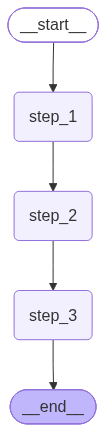

In [37]:
graph

In [39]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


| Symbol | Meaning | Example |
|--------|---------|---------|
| `()` | Function call / arguments | `graph.invoke(...)` |
| `{}` | Dictionary (key-value pairs) | `{"input": "start"}` |
| `[]` | List | `["a", "b"]` |

Here down we are passing None because we need to start from where we got fault tolerance

In [40]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[{'input': 'start', 'step1': 'done', 'step2': 'done'},
 (),
 {'configurable': {'thread_id': 'thread-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f1b5149-520b-63ed-8003-add0f7aba66b'}},
 {'source': 'loop', 'step': 3, 'parents': {}},
 '2026-09-20T16:59:03.111780+00:00',
 {'configurable': {'thread_id': 'thread-1',
   'checkpoint_ns': '',
   'checkpoint_id': '1f1b5149-5208-6c25-8002-74e4d205eefd'}},
 (),
 ()]